In [84]:
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.pipeline import Pipeline

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import os
import sys
SRC_PATH = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(SRC_PATH)

from src import utils
from src.stopwords import STOPWORDS
from src.transformer import TextPreprocessor

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
fname = "../Dataset/movies1000/"
texts, classes = utils.load_movies(fname)
classes = np.array(classes)

In [39]:
texts_samples = [texts[i] for i in range(5)]

In [53]:
text_preprocessor = TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"]).fit(texts)
texts_cleaned = text_preprocessor.transform(texts)

In [97]:
vectorizer = TfidfVectorizer(min_df=5, max_df=0.60, max_features=5000, ngram_range=(1, 2))
vectors = vectorizer.fit_transform(texts_cleaned)
vocab = vectorizer.get_feature_names_out()

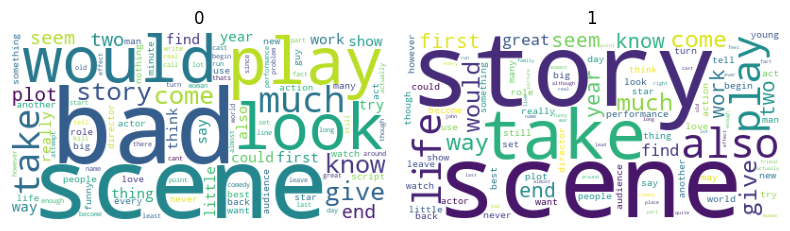

In [98]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes = axes.flatten()

cloud = WordCloud(background_color='white', stopwords = [], max_words=100)

for target in np.unique(classes):
    # Extract data related to target
    idx = np.where(classes == target)[0]
    data_target = [texts_cleaned[i] for i in idx]
    
    # Extract frequencies
    vectors = CountVectorizer(vocabulary=vocab, lowercase=True, ngram_range=(1, 2)).fit_transform(data_target)
    freqs = {word : int(freq) for word, freq in zip(vectorizer.get_feature_names_out(),
                                            vectors.sum(axis=0).A1)}
    
    # Generate wordcloud
    cloud = cloud.generate_from_frequencies(freqs)
    
    axes[target].imshow(cloud)
    axes[target].axis("off")
    axes[target].set_title(target)

plt.tight_layout()

# Models

In [99]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(texts, classes, random_state=42)

In [100]:
pipeline = Pipeline([
    ("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", TfidfVectorizer(min_df=5, max_df=0.60, max_features=5000)),
    ("classifier", MultinomialNB()) # supposed to work better with count vectorizer
])

# # Cross validation
# scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
# print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

0.824
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       257
           1       0.81      0.83      0.82       243

    accuracy                           0.82       500
   macro avg       0.82      0.82      0.82       500
weighted avg       0.82      0.82      0.82       500



In [104]:
pipeline = Pipeline([
    ("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", TfidfVectorizer(min_df=5, max_df=0.60, max_features=5000)),
    ("classifier", LogisticRegression())
])

# # Cross validation
# scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
# print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

0.842
              precision    recall  f1-score   support

           0       0.88      0.80      0.84       257
           1       0.81      0.88      0.84       243

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.85      0.84      0.84       500



In [92]:
pipeline = Pipeline([
    ("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", TfidfVectorizer(min_df=5, max_df=0.60, max_features=5000, ngram_range=(1, 2))),
    ("classifier", LogisticRegression())
])

# # Cross validation
# scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
# print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

0.852
              precision    recall  f1-score   support

           0       0.88      0.82      0.85       257
           1       0.82      0.88      0.85       243

    accuracy                           0.85       500
   macro avg       0.85      0.85      0.85       500
weighted avg       0.85      0.85      0.85       500



In [105]:
pipeline = Pipeline([
    ("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.60, max_features=5000)),
    ("classifier", MultinomialNB())
])

# # Cross validation
# scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
# print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

0.836
              precision    recall  f1-score   support

           0       0.84      0.84      0.84       257
           1       0.83      0.83      0.83       243

    accuracy                           0.84       500
   macro avg       0.84      0.84      0.84       500
weighted avg       0.84      0.84      0.84       500



In [ ]:
pipeline = Pipeline([
    ("preprocess", TextPreprocessor(stem=False, lemmatize=True, lang="english", stopwords=STOPWORDS["english"])),
    ("vectorizer", CountVectorizer(min_df=5, max_df=0.80, max_features=5000, ngram_range=(1, 2))),
    ("classifier", MultinomialNB())
])

# # Cross validation
# scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="accuracy")
# print(f"Scores : {scores}, mean score : {np.mean(scores)}")

# Train/test eval
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print(accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

0.822
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       257
           1       0.82      0.81      0.81       243

    accuracy                           0.82       500
   macro avg       0.82      0.82      0.82       500
weighted avg       0.82      0.82      0.82       500

